In [1]:
import numpy as np
import os
from lcpy.hvs.map_dicts import create_mapping, create_list_with_unique_activities
from lcpy.calculators.econ_calc import FastTeaCalculator
from lcpy.hvs.hvs import create_and_save_dataframes_time_series, plot_stacked_percentage_bar_sub_processes
from lcpy.hvs.hvs_tea import (calculate_undiscounted_cost_contributions_per_process,
                              visualize_stacked_barcharts, npv_results_storage_and_vis,
                              visualize_dataframes_time_series, visualize_npv_in_time,
                              create_dictionary_with_dfs, contribution_per_sub_sub_processes)

# Introduction

 - The LCC and TEA analysis follow a similar logic with the LCA analysis. Each sub-process and the main process are modelled with a dictionary and a list that hold respectively the names of each sub-sub-process and the costs/revenues they cause. In this case a class that handles brightway calculations is not needed, nor the ecoinvent keys are needed to be provided.

 - The costs and revenues caused by the sub-sub-processes can be calculated by the exchange amounts used in the LCA calculations multiplied by the respective market prices. These are undiscounted values as lcpy considers discounting in its functions.

 - The sub-processes and main process can, and is recommended to, be modelled with two dictionaries and two lists with the one pair of dictionary-list representing the cost-generating sub-processes and the other revenue-generating sub-processes. This modelling way will help in the visualization of the results.

 - For an LCC/TEA analysis we consider as a baseline that the capex needs to be considered and that an operational lifetime for the investigated system/process is set with the associated opex and revenues. If an analysis for only 1 time step is desired the cost of infrastructure can be set to 0 and consider only 1 time step.

In [2]:
target_dir = "path_to_directory_to_store_the_results"
os.makedirs(target_dir, exist_ok=True)
scen_names = ['one']
headers = ['Cost breakdown']

Some basic parameters need to be set as well as the discount rate to be considered in the analysis.

We consider 1 year for the construction of the plant and 10 years of operation.

In [3]:
scenarios = 1
timeframe = 10 #operational lifetime after construction
time_step = 1
construction_years = 1
number_of_infrastructure_processes = 1
discount_rate = 0.05

We defined the parametric model

We set the shares for the energy sources feeding the electricity mix

We consider that the plant operates 8000 hours/year, with this being constant for the 10 years of operation.

In [4]:
cap_fac = np.full((scenarios, timeframe // time_step), 8000.)

We define the electricity mix share for the coming 10 years based on capacities that evolve in time (very simplified assumption)

In [5]:
bwr_growth = (1. + 0.02)**(timeframe // time_step)
pwr_growth = (1. - 0.01)**(timeframe // time_step)
hydro_growth = (1. + 0.01)**(timeframe // time_step)
dge_growth = (1. + 0.04)**(timeframe // time_step)
wind_growth = (1. + 0.02)**(timeframe // time_step)

In [6]:
BWR_capacity = np.tile(1500.*bwr_growth, (scenarios, 1))
PWR_capacity = np.tile(800.*pwr_growth, (scenarios, 1))

NG_ccpp_capacity = np.full((scenarios, timeframe // time_step), 400.)
NG_cogen_conv_capacity = NG_ccpp_capacity * np.random.uniform(low=0.1, high=0.1, size=(scenarios, timeframe // time_step))
NG_convpp_capacity = np.full((scenarios, timeframe // time_step), 1100.)
NG_cogen_cc_capacity = np.full((scenarios, timeframe // time_step), 230.)

Hydro_pumped_capacity = np.tile(420.*hydro_growth, (scenarios, 1))
DGE_capacity = np.tile(85.*dge_growth, (scenarios, 1))
Wind_1_3_capacity = np.tile(980.*wind_growth, (scenarios, 1))

In [7]:
total_capacity = BWR_capacity + PWR_capacity + NG_ccpp_capacity + NG_cogen_conv_capacity + NG_convpp_capacity + NG_cogen_cc_capacity + Hydro_pumped_capacity + DGE_capacity + Wind_1_3_capacity

In [8]:
bwr_share = BWR_capacity / total_capacity
pwr_share = PWR_capacity / total_capacity
ng_ccpp_share = NG_ccpp_capacity / total_capacity
ng_cogen_share = NG_cogen_conv_capacity / total_capacity
ng_convpp_share = NG_convpp_capacity / total_capacity
ng_cogen_cc_share = NG_cogen_cc_capacity / total_capacity
hydro_share = Hydro_pumped_capacity / total_capacity
dge_share = DGE_capacity / total_capacity
wind_share = Wind_1_3_capacity / total_capacity

We consider an electriicity consumption of 100 kWh (constant)

In [9]:
electricity_consumption = np.full((scenarios, timeframe // time_step), 100.)

We define the electricity price for the coming 10 years starting with 0.016 EUR/kWh

In [10]:
elec_price = np.zeros((scenarios, timeframe // time_step))

In [11]:
for i in range(scenarios):
    elec_price[i,0] = 0.016
    for j in range(1, timeframe // time_step):
        elec_price[i,j] = elec_price[i,j-1]*(1+0.01)

We also consider that 10% of the consumed electricity is produced during the process and sold to the grid at a slightly lower price than that bought (just for demonstration)


In [12]:
electricity_production = np.full((scenarios, timeframe // time_step), 10.)

In [13]:
elec_selling_price = np.zeros((scenarios, timeframe // time_step))
for i in range(scenarios):
    elec_selling_price[i, 0] = 0.014
    for j in range(1, timeframe // time_step):
        elec_selling_price[i, j] = elec_selling_price[i, j - 1] * (1 + 0.01)

In [14]:
butanol_consumption = np.full((scenarios, timeframe // time_step), 80.)
other_chemical_consumption = np.ones((scenarios, timeframe // time_step))

In [15]:
for i in range(scenarios):
    for j in range(timeframe // time_step):
        other_chemical_consumption[i, j] = 40. + (40. * 0.01*j)

In [16]:
total_fu = np.full((scenarios, timeframe // time_step), 1.)

In [17]:
for i in range(scenarios):
    for j in range(timeframe // time_step):
        total_fu[i, j] = 50. + (30. * 0.05*j)

In [18]:
total_fu = total_fu

In [19]:
waste_material = butanol_consumption + other_chemical_consumption - total_fu

In [20]:
total_fu = total_fu

We also define the prices for the chemicals used, the cost of waste management, and also the price of our product (functional unit)

In [21]:
butanol_price = np.full((scenarios, timeframe // time_step), 0.1)
other_chemical_price = np.full((scenarios, timeframe // time_step), 0.15)
waste_handling_price = np.full((scenarios, timeframe // time_step), 0.0346)

We define the Capex (a small one)

In [22]:
building_amount = np.full((scenarios, construction_years),1.)

In [23]:
buiding_price = np.full((scenarios, construction_years),110.)

And lastly we define the product price to calculate the revenues

In [24]:
product_price = np.zeros((scenarios, timeframe // time_step))
for i in range(scenarios):
    product_price[i, 0] = 0.8
    for j in range(1, timeframe // time_step):
        product_price[i, j] = product_price[i, j - 1] * (1 + 0.01)

We set two dummies for convenience

In [25]:
dummy_parameter = np.full((scenarios, timeframe//time_step),1.)
dummy_parameter_construction = np.full((scenarios, construction_years),1.)

We also set the discount rate

In [26]:
discount_factors = np.exp(-discount_rate*np.arange(timeframe//time_step))

And for completion we consider a personnel cost as well

In [27]:
personnel_cost = np.full((scenarios, timeframe//time_step), 3.)

We proceed with defining the dictionaries and lists that model each sub-process.

Below we model the sub-process for the construction (capex). We include a dictionary and list for the revenues that can arise from this sub-process, though not having any revenues. The dicitonary is empty and the list contains a zeros array.

In [28]:
construction_costs_keys = {
    'Building': '', # Note that we do not need ecoinvent keys, in contrast to the LCA examples
}

construction_costs_amounts = [
    building_amount*buiding_price
]

construction_revenues_keys = {
    '': '',
}

construction_revenues_amounts = [
    0*dummy_parameter_construction
]


In [29]:
electricity_and_personnel_costs_keys = {
    'Electricity consumption': '',
    'Personnel': ''
}

electricity_and_personnel_costs_amounts = [
    elec_price * electricity_consumption,
    personnel_cost
]

electricity_and_personnel_revenues_keys = {
    'Electricity production': '',
}

electricity_and_personnel_revenues_amounts = [
    elec_selling_price * electricity_production
]

chemical_consumption_costs_keys = {
    'Butanol consumption' :  '',
    'Other chemical consumption' :  '',
}

chemical_consumption_costs_amounts = [
    butanol_consumption * butanol_price,
    other_chemical_price * other_chemical_consumption,
]

chemical_consumption_revenues_keys = {
    '': '',
}

chemical_consumption_revenues_amounts = [
    0*dummy_parameter
]

waste_management_costs_keys = {
    'Waste' :  '',
}

waste_management_costs_amounts = [
    waste_handling_price * waste_material,
]

waste_management_revenues_keys = {
    '': ''
}

waste_management_revenues_amounts = [
    0*dummy_parameter,
]

final_product_costs_keys = {
    '' :  '',
}

final_product_costs_amounts = [
    0*dummy_parameter,
]

final_product_revenues_keys = {
    'Chemical production' : '',
}

final_product_revenues_amounts = [
    total_fu * product_price,
]

And we define the dictionary and list for the main process (only one pair of dictionary and list is needed now).

Since we have put absolute costs and revenues above and not per F.U. we put 1 in the exchanges amounts

In [30]:
keys_main_process = {
'Infrastructure': '',
'Electricity and personnel' :  '',
'Chemical consumption' :  '',
'Waste management' :  '',
'Product production' :  '',
}

exchanges_amounts_main_process = [
    1.*dummy_parameter,
    1.*dummy_parameter,
    1.*dummy_parameter,
    1.*dummy_parameter,
    1.*dummy_parameter,
]


Similarly with the LCA examples we need to group the keys dictionaries and the amount lists in lists

In [31]:
list_with_keys_costs = [construction_costs_keys, electricity_and_personnel_costs_keys, chemical_consumption_costs_keys, waste_management_costs_keys, final_product_costs_keys]

list_with_keys_revenues = [construction_revenues_keys, electricity_and_personnel_revenues_keys, chemical_consumption_revenues_keys, waste_management_revenues_keys, final_product_revenues_keys]

exchanges_revenues_list = [construction_revenues_amounts, electricity_and_personnel_revenues_amounts, chemical_consumption_revenues_amounts, waste_management_revenues_amounts, final_product_revenues_amounts]

exchanges_list = [construction_costs_amounts, electricity_and_personnel_costs_amounts, chemical_consumption_costs_amounts, waste_management_costs_amounts, final_product_costs_amounts]

We create mapping dictionaries similary to the process of the LCA example.

We create different dictionaries for the operational processes, construction processes, and for all process (this will be handy later)
We create different mappings for the costs and the revenues

In [32]:
mapping_names_costs = create_mapping(keys_main_process, list_with_keys_costs, number_of_infrastructure_processes, tea_op=True)
mapping_names_construction_costs = create_mapping(keys_main_process, list_with_keys_costs, number_of_infrastructure_processes, tea_con=True)
mapping_names_total_costs = create_mapping(keys_main_process, list_with_keys_costs)

In [33]:
mapping_names_revenues = create_mapping(keys_main_process, list_with_keys_revenues, number_of_infrastructure_processes, tea_op=True)
mapping_names_construction_revenues = create_mapping(keys_main_process, list_with_keys_revenues, number_of_infrastructure_processes, tea_con=True)
mapping_names_total_revenues = create_mapping(keys_main_process, list_with_keys_revenues)

In [34]:
mapping_exchanges_costs = create_mapping(keys_main_process, exchanges_list, number_of_infrastructure_processes, tea_op=True)
mapping_exchanges_construction_costs = create_mapping(keys_main_process, exchanges_list, number_of_infrastructure_processes, tea_con=True)
mapping_exchanges_total_costs = create_mapping(keys_main_process, exchanges_list)

In [35]:
mapping_exchanges_revenues = create_mapping(keys_main_process, exchanges_revenues_list, number_of_infrastructure_processes, tea_op=True)
mapping_exchanges_construction_revenues = create_mapping(keys_main_process, exchanges_revenues_list, number_of_infrastructure_processes, tea_con=True)
mapping_exchanges_total_revenues = create_mapping(keys_main_process, exchanges_revenues_list)

We create a list with unique names of sub-sub-processes occurring among the sub-processes

In [36]:
unique_activities_cost = create_list_with_unique_activities(list_with_keys_costs)
unique_activities_rev = create_list_with_unique_activities(list_with_keys_revenues)

In [37]:
# mapping_elec = {
#     'Electricity': list(keys_electricity_consumtpion.keys())[number_of_infrastructure_processes:]
#     }
# mapping_exch_elec = create_mapping(mapping_elec, [electricity_consumption_exchanges_amounts])

In [38]:
# mapping_elec = {
#     'Electricity': list(keys_electricity_consumtpion.keys())[number_of_infrastructure_processes:]
#     }
# mapping_exch_elec = create_mapping(mapping_elec, [electricity_consumption_exchanges_amounts[number_of_infrastructure_processes:]])

We also create (mannualy since it is easy) the mapping dictionaries for the main process

In [39]:
mapping_main_process = {
    'Main process': list(keys_main_process.keys())
    }
mapping_exch_main_process = create_mapping(mapping_main_process, [exchanges_amounts_main_process])

We create a fast calculator instance (this is powered by cython functions for the case that millions scenarios are examined and a very low temporal dimension is used)

In [40]:
my_calculator = FastTeaCalculator(number_of_infrastructure_processes, construction_years, scenarios, discount_rate)

We calculate the cost of each sub-process and per sub-sub-process discounted at the first operational year. We run the same function for the infrastructural sub-process
setting the infrastructure boolean to True, so we keep the infrastructural costs at the year they occur. We do the same for the revenues. The results are stored in attributes of the my_calculator instance. The costst change sign to become negative values, while the sign of the revenues remain the same.

In [41]:
my_calculator.cost_calculation(mapping_exchanges_costs, discount_factors)
my_calculator.cost_calculation(mapping_exchanges_construction_costs, discount_factors, infrastructure=True)

In [42]:
my_calculator.revenue_calculation(mapping_exchanges_revenues, discount_factors)

We can now examine the cost/revenues contributions per sub-process and for the main process (undiscounted) with the below functions that create barcharts and save these results in excel files

In [43]:
#Saving and visualizing
calculate_undiscounted_cost_contributions_per_process(mapping_names_costs, mapping_names_construction_costs, mapping_exchanges_costs, mapping_exchanges_construction_costs, headers,
                                                      mapping_main_process, target_dir)

C:\Users\sgkousis\Desktop\lcpy\lcpy\hvs\hvs_tea.py:84: RuntimeWarning: invalid value encountered in divide
  percentages = (no_impact / no_sum) * 100
C:\Users\sgkousis\Desktop\lcpy\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))


Excel file saved as C:\Users\sgkousis\Desktop\Example_results\LCC_and_TEA\scen_0_year_0__cost_breakdown.xlsx
Excel file saved as C:\Users\sgkousis\Desktop\Example_results\LCC_and_TEA\scen_0_year_0__cost_total.xlsx


C:\Users\sgkousis\Desktop\lcpy\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))


In [44]:
#Saving and visualizing the revenues
calculate_undiscounted_cost_contributions_per_process(mapping_names_revenues, mapping_names_construction_revenues, mapping_exchanges_revenues,
                                                      mapping_exchanges_construction_revenues, headers,
                                                      mapping_main_process, target_dir, file_name_total= 'Revenues_total.xlsx',
                                                      file_name_contributions='Revenues_contributions.xlsx', rev = 'revenues');

C:\Users\sgkousis\Desktop\lcpy\lcpy\hvs\hvs_tea.py:84: RuntimeWarning: invalid value encountered in divide
  percentages = (no_impact / no_sum) * 100
C:\Users\sgkousis\Desktop\lcpy\lcpy\hvs\hvs_tea.py:84: RuntimeWarning: invalid value encountered in divide
  percentages = (no_impact / no_sum) * 100
C:\Users\sgkousis\Desktop\lcpy\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
C:\Users\sgkousis\Desktop\lcpy\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
C:\Users\sgkousis\Desktop\lcpy\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose la

Excel file saved as C:\Users\sgkousis\Desktop\Example_results\LCC_and_TEA\scen_0_year_0_revenues_Revenues_total.xlsx


C:\Users\sgkousis\Desktop\lcpy\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
C:\Users\sgkousis\Desktop\lcpy\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
C:\Users\sgkousis\Desktop\lcpy\lcpy\hvs\hvs_tea.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))


Excel file saved as C:\Users\sgkousis\Desktop\Example_results\LCC_and_TEA\scen_0_year_0_revenues_Revenues_contributions.xlsx


We can next calculate the in time evolution, cumulatively and non-cumulatively, of the costs of the main process and per sub-process (held in attributes of my_calculator). These are all considering the costs are discounted at the firts operational year. We do the same for the revenues. We can add discounting to the first construction year by setting the add_disc parameter.

In [45]:
my_calculator.total_cost_calculation(discount_factors, 'Main process')
my_calculator.total_revenue_calculation(discount_factors, 'Main process')
my_calculator.total_cost_calculation_including_infrastructure(discount_factors, 'Main process')

We need to restruvture the revenue dictionaries for later use.

In [46]:
my_calculator.refine_revenue_dicts(name = 'Main process')

Below we create (and save/visualize) dataframes holding the information calculated with the above functions.

In [47]:
dataframes_total_non_cum_cos = create_and_save_dataframes_time_series(my_calculator.non_cum_cost_infr['Main process'], ['Non-cumulative-cost'], scen_names, excel_file_name= os.path.join(target_dir, 'non_cumulative_cost_output.xlsx'))

Dataframes not save, set save to True to save them


In [48]:
dataframes_total_cum_cost = create_and_save_dataframes_time_series(my_calculator.cum_cost_infr['Main process'], ['Cumulative-cost'], scen_names, excel_file_name= os.path.join(target_dir, 'cumulative_cost_output.xlsx'))

Dataframes not save, set save to True to save them


In [49]:
dataframes_total_cum_rev = create_and_save_dataframes_time_series(my_calculator.cum_revenue['Main process'], ['Cumulative Revenues'], scen_names, excel_file_name= os.path.join(target_dir, 'cumulative_revenues_output.xlsx'))

Dataframes not save, set save to True to save them


In [50]:
dataframes_total_non_cum_rev = create_and_save_dataframes_time_series(my_calculator.non_cum_revenue['Main process'], ['Revenues'], scen_names, excel_file_name= os.path.join(target_dir, 'non_cumulative_revenues_output.xlsx'))

Dataframes not save, set save to True to save them


In [51]:
visualize_dataframes_time_series(dataframes_total_non_cum_cos, ['Non-cumulative-cost'], scen_names, 'Years', 'Cost in EUR', 'Non-cumulative-cost', os.path.join(target_dir, 'non_cumulative_cost_output.png'))

In [52]:
visualize_dataframes_time_series(dataframes_total_cum_cost, ['Cumulative-cost'], scen_names, 'Years', 'Cost in EUR', 'Cumulative-cost', os.path.join(target_dir, 'cumulative_cost_output.png'))

In [53]:
visualize_dataframes_time_series(dataframes_total_cum_rev, ['Cumulative-revenue'], scen_names, 'Years', 'Revenue in EUR', 'Non-cumulative-revenue', os.path.join(target_dir, 'cumulative_revenue_output.png'))

In [54]:
visualize_dataframes_time_series(dataframes_total_non_cum_rev, ['Non-cumulative-revenue'], scen_names, 'Years', 'Revenue in EUR', 'Cumulative-revenue', os.path.join(target_dir, 'non_cumulative_revenue_output.png'))

We have saved above the evolution of the costs and revenues occurring at each time step and for each scenario. We can now visualize the NPV evolution in time, for all, or for selected, scenarios.

In [55]:
visualize_npv_in_time(dataframes_total_cum_rev, dataframes_total_cum_cost, scen_names, os.path.join(target_dir, 'npv_all_scenarios.png'))
visualize_npv_in_time(dataframes_total_cum_rev, dataframes_total_cum_cost, ['one'], os.path.join(target_dir, f"npv_scen_one.png"))

And we can also create barcharts that show the contribution of each sub-process to the cost of the main process and its evolution in time. we can set a step for the visualization.

In [56]:
visualize_stacked_barcharts(mapping_names_costs, my_calculator.non_cum_cost_per_process['Main process'],
                            scen_names, 7, os.path.join(target_dir, 'stacked_barchart.png'), 'one', 'Contribution (%)', 'Years', ' ')

In [57]:
visualize_stacked_barcharts(mapping_names_total_costs, my_calculator.non_cum_cost_per_process_infr['Main process'], scen_names, 2, os.path.join(target_dir, 'stacked_barchart_inrf.png'), 'one', 'Contribution (%)', 'Years', ' ')

We can now calculate the NPV (before we simply visualized it)

In [58]:
my_calculator.npv_calculation(discount_factors, name = 'Main process')

The above calculation of the NPV only considers the costs and revenues projected by the modelling. We can include some more parameters such as tax, loan, and depreciation using the below function for NPV calculation, though we must first define these parameters.

In [59]:
tax_rate = 0.2
loan_percentage = 0.3
loan_years = 5
loan_rate = 0.02
depreciation_years = 5

my_calculator.npv_calculation_depreciation(discount_factors, 'Main process', tax_rate,
                                           loan_percentage, loan_years, loan_rate, depreciation_years)

We can calculate the levelized cost of product (e.g., energy) with the below function. The total_fu needs to be wrapped in a list before getting passed in the function. The lcoe calculation only considers the costs,  not the revenues (thus only information included initially in the cost dictionaries).

In [60]:
my_calculator.lcoe_calculation([total_fu], discount_factors, 'Main process')

We can also calculate the annualized cost per each operational year.

In [61]:
my_calculator.annualized_cost_calculation('Main process')

Below we create a list with the parameters we want to save and visualize, and a list with the respective names we want them saved and visualized as. We can then use the npv_results_storage_and_vis function to store and visualzie these results.

In [62]:
list_for_storage_and_vis_function = [my_calculator.npv['Main process'], my_calculator.total_costs['Main process'],
                            my_calculator.operational_costs['Main process'], my_calculator.total_revenue['Main process'],
                            my_calculator.lcoe['Main process']]
names_for_storage_and_vis_function = ['NPV', 'Total Cost', 'Operational Cost', 'Total Revenue', 'LCOE']
names_for_y_axis_of_boxplots = ['million EUR', 'million EUR', 'million EUR', 'million EUR', 'EUR/kg' ]

npv_results_storage_and_vis(list_for_storage_and_vis_function, names_for_storage_and_vis_function, names_for_y_axis_of_boxplots, target_dir, 'boxplot_results.xlsx')

We have not created and saved dataframes for the LCOE. Let's do this

In [63]:
dataframes_lcoe = create_and_save_dataframes_time_series(my_calculator.lcoe_in_time['Main process'], ['LCOE'], scen_names, os.path.join(target_dir, 'lcoe_in_time.xlsx'))
visualize_dataframes_time_series(dataframes_lcoe, ['LCOE'], scen_names, 'Years', 'EUR/kg', 'LCOE', os.path.join(target_dir, 'lcoe_in_time'), offset = construction_years)

Dataframes not save, set save to True to save them


And finally below we create some dictionaries with the cost and contribution to cost for each sub-process and save them. These can be used for visualization and results inspection.

In [64]:
dict_with_dfs_cost, dict_with_dfs_cost_contr = create_dictionary_with_dfs(mapping_names_costs, my_calculator.cost_per_process, 0, 'Cost')
dict_with_dfs_revenues, dict_with_dfs_revenues_contr = create_dictionary_with_dfs(mapping_names_revenues, my_calculator.revenue_per_process, 0, 'Revenues')

In [65]:
cost_per_sub_sub_process_dict =  contribution_per_sub_sub_processes(dict_with_dfs_cost, dict_with_dfs_cost_contr, unique_activities_cost, ['Cost'], name= 'main_process', save = 'True', target_dir = target_dir)

In [66]:
cost_per_sub_sub_process_dict

{'Cost':                                 Value
 Key                                  
 Butanol consumption         64.542087
 Other chemical consumption  50.386019
 Personnel                   24.203283
 Waste                       18.284483
 Electricity consumption     13.449914
                             -0.000000
 Building                    -0.000000}

In [67]:
revenue_per_sub_sub_process_dict =  contribution_per_sub_sub_processes(dict_with_dfs_revenues, dict_with_dfs_revenues_contr, unique_activities_rev,
                                   ['Revenues'], sign = 1, name= 'main_process', save = 'True', target_dir = target_dir)

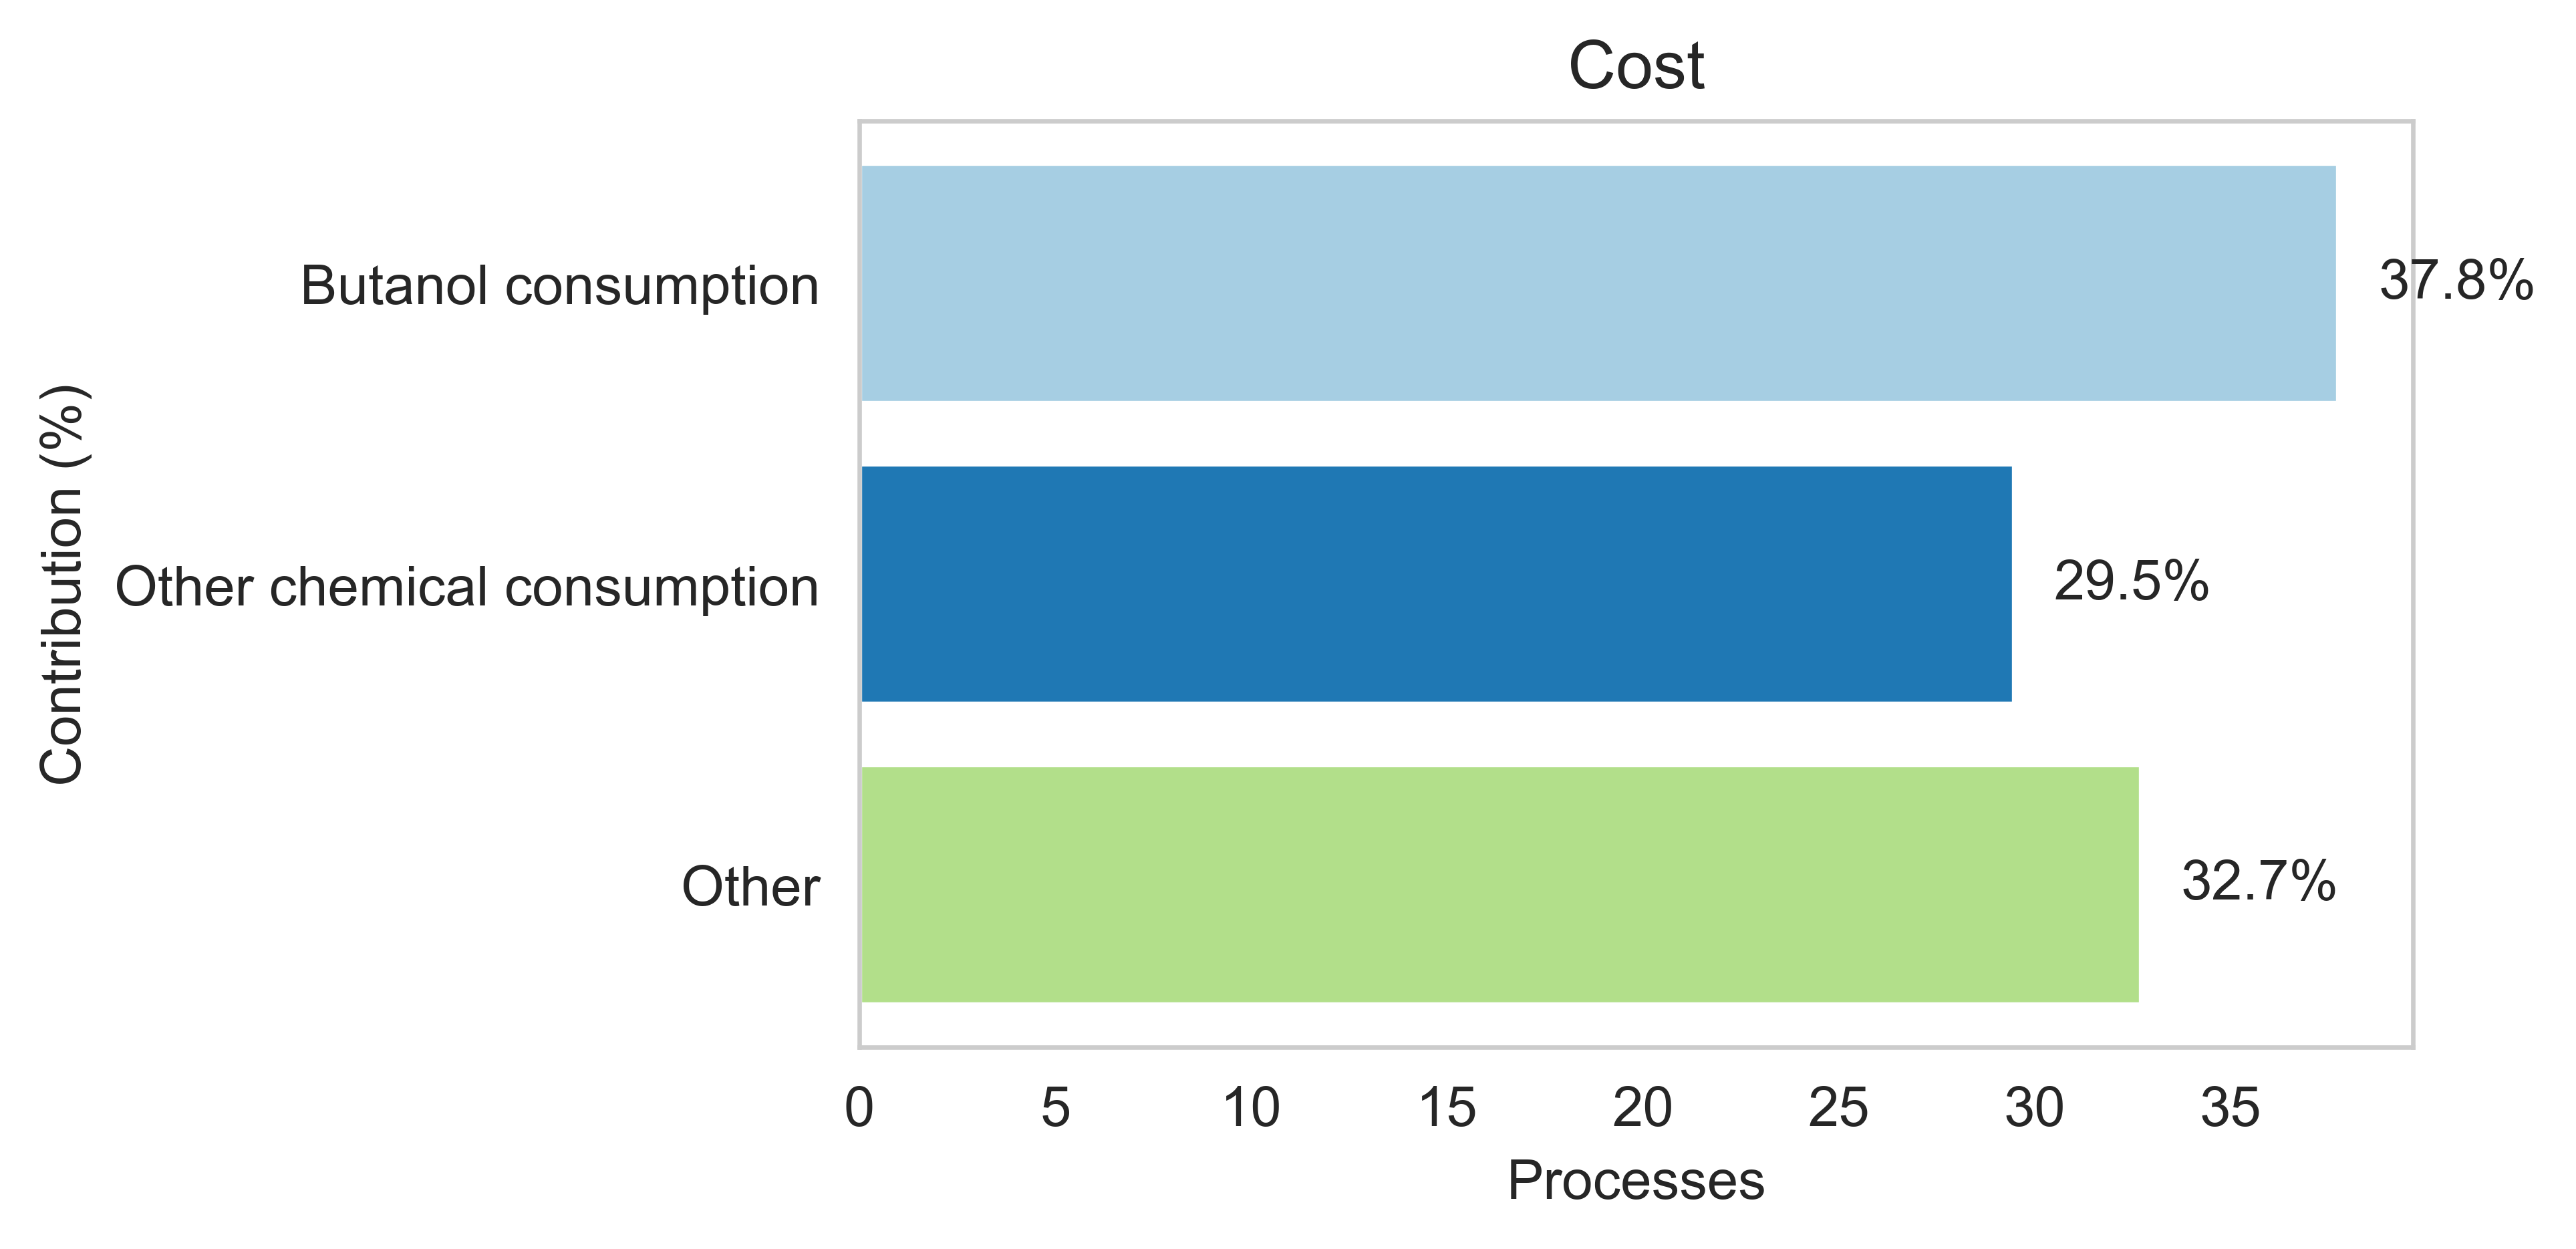

In [68]:
plot_stacked_percentage_bar_sub_processes(cost_per_sub_sub_process_dict, 'Cost', os.path.join(target_dir, f"sub_process_contributions_cost.png"), verbose = 'False', top_x = 2 )

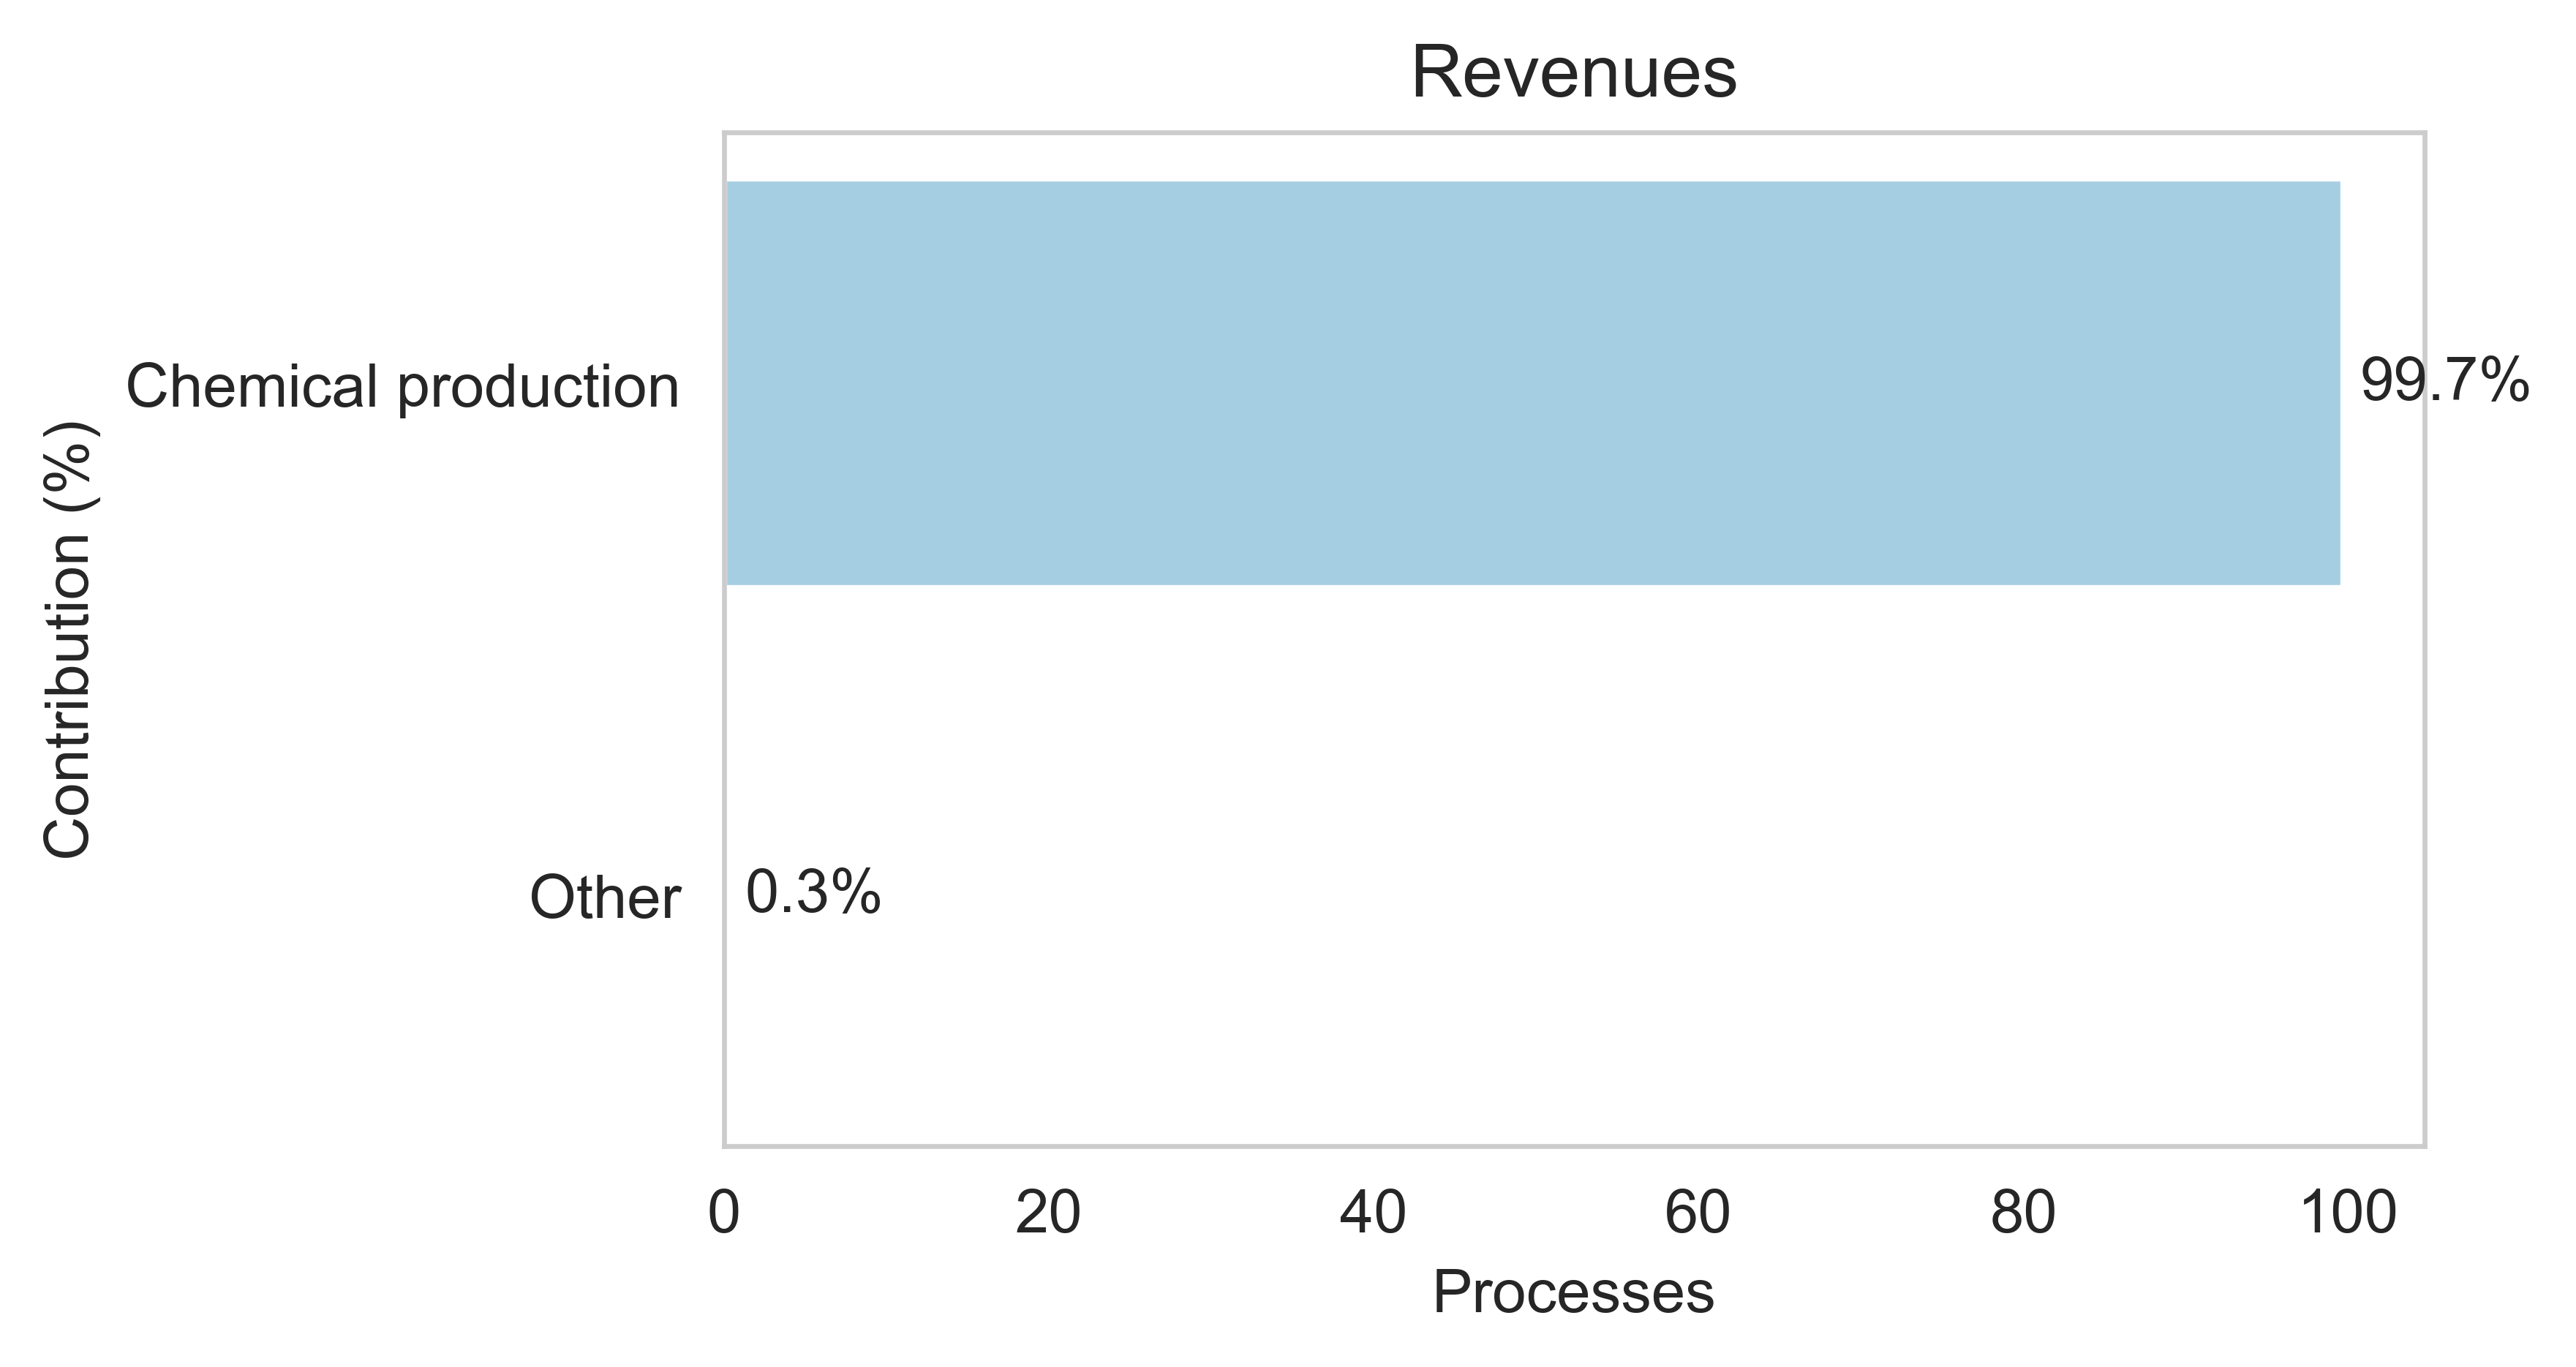

In [69]:
plot_stacked_percentage_bar_sub_processes(revenue_per_sub_sub_process_dict, 'Revenues', os.path.join(target_dir, f"sub_process_contributions_revenue.png"), verbose = 'False', top_x = 1 )

The below function can be used to calculate the minimum selling price for the product. However, this function takes into account all revenues and costs considered. Thus, to calculate the MSP for the functional unit, the associate revenues from its sale need to be set to 0 during the definition of the dicitonaries and lists modelling the costs and revenues of the sub-processes and main process.

This function thus cannot be used in the same notebook with the calculation of NPV. A new analysis should be made considering the revenues from the functional unit 0. The function can be run directly after the cost and revenue calculation functions.

In [70]:
# my_calculator.msp_calculation(discount_factors, 'Main process', [total_fu])

# The main process as a sub-process

Similarly to the LCA examples the calculated main process above (or any externally calculated main process) can be used as a sub-process in another main process calculation. In contrast to the LCA case where complex appends are done here the previously main process can be modelled directly with two dictionaries and two lists representing the cost- and revenue-generating activities. Since we have performed the analysis for the latter, we can only use one sub-sub-process for the costs and one for the revenues, and use a function of the my_calculator instance that sums these costs adn revenues as modelled previously. Alternatively, the costs/revenues can be input mannualy as before. Note that the construction and operational sub-processes of the previous main process have to be considered separately in the modelling of the new main process. Below we show how this can be done.

### Modelling of the construction phase
We consider only the infrastructural activities of the previosu main process.

In [71]:
number_of_infrastructure_processes_2 = 1

We create the dictionaries

In [72]:
keys_infrastructure_costs = {
    "Previous main process infrastructure": ""
}

keys_infrastructure_revenues = {
    '': '',
}

We create the lists with the costs/revenues by using the sum_sub_process function of the previous my_calculator instance. We sum until the first operational sub-process

In [73]:
exchanges_amounts_infrastructure_costs =[
    my_calculator.sum_sub_process(exchanges_list[:number_of_infrastructure_processes])
]

exchanges_amounts_infrastructure_revenues =[
    my_calculator.sum_sub_process(exchanges_revenues_list[:number_of_infrastructure_processes])
]

We do the same for the operational sub-processes of the previosu main process

In [74]:
keys_old_mp_costs = {
'Previous main process' :  '',
}

exchanges_old_mp_costs = [
    my_calculator.sum_sub_process(exchanges_list[number_of_infrastructure_processes:])
]

keys_old_mp_revenues = {
'Previous main process' :  '',
}

exchanges_old_mp_revenues = [
    my_calculator.sum_sub_process(exchanges_revenues_list[number_of_infrastructure_processes:])
]

And finally we continue with modelling the new sub-processes (we are going to use the same as before for simplicity and without the waste managament activity).

In [75]:
electricity_and_personnel_costs_keys = {
    'Electricity consumption': '',
    'Personnel': ''
}

electricity_and_personnel_costs_amounts = [
    elec_price * electricity_consumption,
    personnel_cost
]

electricity_and_personnel_revenues_keys = {
    'Electricity production': '',
}

electricity_and_personnel_revenues_amounts = [
    elec_selling_price * electricity_production
]

chemical_consumption_costs_keys = {
    'Butanol consumption' :  '',
    'Other chemical consumption' :  '',
}

chemical_consumption_costs_amounts = [
    butanol_consumption * butanol_price,
    other_chemical_price * other_chemical_consumption,
]

chemical_consumption_revenues_keys = {
    '': '',
}

chemical_consumption_revenues_amounts = [
    0*dummy_parameter
]

final_product_costs_keys = {
    '' :  '',
}

final_product_costs_amounts = [
    0*dummy_parameter,
]

final_product_revenues_keys = {
    'Chemical production' : '',
}

final_product_revenues_amounts = [
    total_fu * product_price,
]

In [76]:
keys_new_main_process = {
    'Infrastructure': '',
    'Electricity and personnel': '',
    'Chemical consumption': '',
    'Product production': '',
}

exchanges_amounts_new_main_process = [
    1. * dummy_parameter,
    1. * dummy_parameter,
    1. * dummy_parameter,
    1. * dummy_parameter,
]

In [77]:
list_with_keys_costs = [keys_infrastructure_costs, keys_old_mp_costs, electricity_and_personnel_costs_keys,
                        chemical_consumption_costs_keys, final_product_costs_keys]

list_with_keys_revenues = [keys_infrastructure_revenues, keys_old_mp_revenues, electricity_and_personnel_revenues_keys,
                        chemical_consumption_revenues_keys, final_product_revenues_keys]

exchanges_revenues_list = [exchanges_amounts_infrastructure_revenues, exchanges_old_mp_revenues, electricity_and_personnel_revenues_amounts,
                           chemical_consumption_revenues_amounts, final_product_revenues_amounts]

exchanges_list = [exchanges_amounts_infrastructure_costs, exchanges_old_mp_costs, electricity_and_personnel_costs_amounts,
                  chemical_consumption_costs_amounts, final_product_costs_amounts]

The rest modelling is identical to what shown above for the initial process